In [1]:
# pip install torch torchvision timm albumentations opencv-python pandas scikit-learn tqdm

import os
import cv2
import torch
import numpy as np
import pandas as pd
import albumentations as A

from tqdm import tqdm
from PIL import Image
from sklearn.model_selection import train_test_split

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import timm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [3]:
TRAIN_PATH = "../../dataset/noise_removed/train"
TEST_PATH = "../../dataset/noise_removed/test"

SUBMISSION_PATH = "../../samplesubmission.csv"

In [4]:
classes = [
    "fake_mannequin",
    "fake_mask",
    "fake_printed",
    "fake_screen",
    "fake_unknown",
    "realperson"
]

label2id = {c:i for i,c in enumerate(classes)}
id2label = {i:c for c,i in label2id.items()}

label2id

{'fake_mannequin': 0,
 'fake_mask': 1,
 'fake_printed': 2,
 'fake_screen': 3,
 'fake_unknown': 4,
 'realperson': 5}

In [5]:
data = []

for label in classes:

    folder = os.path.join(TRAIN_PATH, label)

    for img in os.listdir(folder):

        data.append({
            "path": os.path.join(folder, img),
            "label": label2id[label]
        })

train_df = pd.DataFrame(data)

print("Total training images:", len(train_df))
train_df.head()

Total training images: 1454


,path,label
0,../../dataset/noise_removed/train\fake_mannequ...,0
1,../../dataset/noise_removed/train\fake_mannequ...,0
2,../../dataset/noise_removed/train\fake_mannequ...,0
3,../../dataset/noise_removed/train\fake_mannequ...,0
4,../../dataset/noise_removed/train\fake_mannequ...,0


In [6]:
train_tfms = A.Compose([
    A.Resize(256,256),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.GaussianBlur(p=0.2),
    A.ColorJitter(p=0.3),
])

test_tfms = A.Compose([
    A.Resize(256,256)
])

In [7]:
class FaceDataset(Dataset):

    def __init__(self, df, transforms=None):

        self.df = df.reset_index(drop=True)
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        img = cv2.imread(row.path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transforms:
            img = self.transforms(image=img)["image"]

        img = img.astype(np.float32) / 255.0
        img = np.transpose(img,(2,0,1))

        label = row.label

        return torch.tensor(img), torch.tensor(label)

In [8]:
train_dataset = FaceDataset(train_df, train_tfms)

In [9]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

In [10]:
model = timm.create_model(
    "efficientnet_b0",
    pretrained=True,
    num_classes=6
)

model = model.to(device)

print("Model loaded")

Model loaded


In [11]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=3e-4
)

In [12]:
def train_one_epoch(loader):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for imgs, labels in tqdm(loader):

        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(imgs)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        preds = outputs.argmax(1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    acc = correct / total

    return total_loss / len(loader), acc

In [13]:
EPOCHS = 5

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(train_loader)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Loss: {train_loss:.4f} | "
        f"Accuracy: {train_acc:.4f}"
    )

100%|██████████| 46/46 [02:09<00:00,  2.82s/it]


Epoch 1/5 | Loss: 1.0578 | Accuracy: 0.7070


100%|██████████| 46/46 [02:08<00:00,  2.79s/it]


Epoch 2/5 | Loss: 0.2570 | Accuracy: 0.9243


100%|██████████| 46/46 [02:03<00:00,  2.68s/it]


Epoch 3/5 | Loss: 0.1589 | Accuracy: 0.9587


100%|██████████| 46/46 [02:03<00:00,  2.68s/it]


Epoch 4/5 | Loss: 0.1419 | Accuracy: 0.9615


100%|██████████| 46/46 [02:00<00:00,  2.62s/it]

Epoch 5/5 | Loss: 0.1230 | Accuracy: 0.9684


In [14]:
torch.save(model.state_dict(), "efficientnet_baseline.pth")

print("Model saved.")

Model saved.


In [15]:
submission_df = pd.read_csv(SUBMISSION_PATH)

submission_df.head()

,id,label
0,test_001,NaN
1,test_002,NaN
2,test_003,NaN
3,test_004,NaN
4,test_005,NaN


In [21]:
test_paths = []

for img_id in submission_df["id"]:

    found = False

    for ext in [".jpg", ".jpeg", ".png"]:

        img_path = os.path.join(TEST_PATH, img_id + ext)

        if os.path.exists(img_path):
            test_paths.append(img_path)
            found = True
            break

    if not found:
        print("Missing:", img_id)

test_df = pd.DataFrame({
    "path": test_paths
})

In [22]:
class TestDataset(Dataset):

    def __init__(self, df, transforms=None):

        self.df = df
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        path = self.df.iloc[idx].path

        img = cv2.imread(path)

        if img is None:
            raise ValueError(f"Image not found: {path}")

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


        if self.transforms:
            img = self.transforms(image=img)["image"]

        img = img.astype(np.float32) / 255.0
        img = np.transpose(img,(2,0,1))

        return torch.tensor(img)

In [24]:
test_dataset = TestDataset(test_df, test_tfms)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

model.eval()

predictions = []

with torch.no_grad():

    for imgs in tqdm(test_loader):

        imgs = imgs.to(device)

        outputs = model(imgs)

        preds = outputs.argmax(1).cpu().numpy()

        predictions.extend(preds)

100%|██████████| 13/13 [00:19<00:00,  1.52s/it]


In [25]:
submission_df["label"] = [id2label[p] for p in predictions]

submission_df.head()

,id,label
0,test_001,fake_printed
1,test_002,fake_mannequin
2,test_003,realperson
3,test_004,realperson
4,test_005,fake_printed


In [26]:
submission_df.to_csv("submission.csv", index=False)

print("Submission saved.")

Submission saved.


In [27]:
from sklearn.metrics import classification_report, f1_score, confusion_matrix

In [31]:
pred_df = pd.read_csv("submission.csv")
anot_df = pd.read_csv("../../samplesubmission_anotated_final.csv", sep=";")

print("Prediction shape:", pred_df.shape)
print("Anotated:", anot_df.shape)

pred_df.head()

Prediction shape: (404, 2)
Anotated: (404, 2)


,id,label
0,test_001,fake_printed
1,test_002,fake_mannequin
2,test_003,realperson
3,test_004,realperson
4,test_005,fake_printed


In [33]:
df = anot_df.merge(pred_df, on="id", suffixes=("_anot", "_pred"))

df.head()

,id,label_anot,label_pred
0,test_001,fake_screen,fake_printed
1,test_002,fake_mannequin,fake_mannequin
2,test_003,realperson,realperson
3,test_004,realperson,realperson
4,test_005,fake_screen,fake_printed


In [35]:
df["y_true"] = df["label_true"].map(label2id)
df["y_pred"] = df["label_pred"].map(label2id)

In [36]:
macro_f1 = f1_score(df["y_true"], df["y_pred"], average="macro")

print("Macro F1 Score:", macro_f1)

Macro F1 Score: 0.8899004445522128


In [37]:
print(classification_report(
    df["y_true"],
    df["y_pred"],
    target_names=classes
))

                precision    recall  f1-score   support

fake_mannequin       0.94      1.00      0.97        47
     fake_mask       0.77      0.95      0.85        66
  fake_printed       0.87      0.77      0.81        60
   fake_screen       0.92      0.88      0.90        74
  fake_unknown       0.90      0.94      0.92        50
    realperson       0.94      0.84      0.89       107

      accuracy                           0.89       404
     macro avg       0.89      0.90      0.89       404
  weighted avg       0.89      0.89      0.89       404



In [38]:
cm = confusion_matrix(df["y_true"], df["y_pred"])

cm

array([[47,  0,  0,  0,  0,  0],
       [ 0, 63,  0,  1,  1,  1],
       [ 1,  4, 46,  3,  2,  4],
       [ 0,  1,  5, 65,  2,  1],
       [ 1,  1,  1,  0, 47,  0],
       [ 1, 13,  1,  2,  0, 90]])

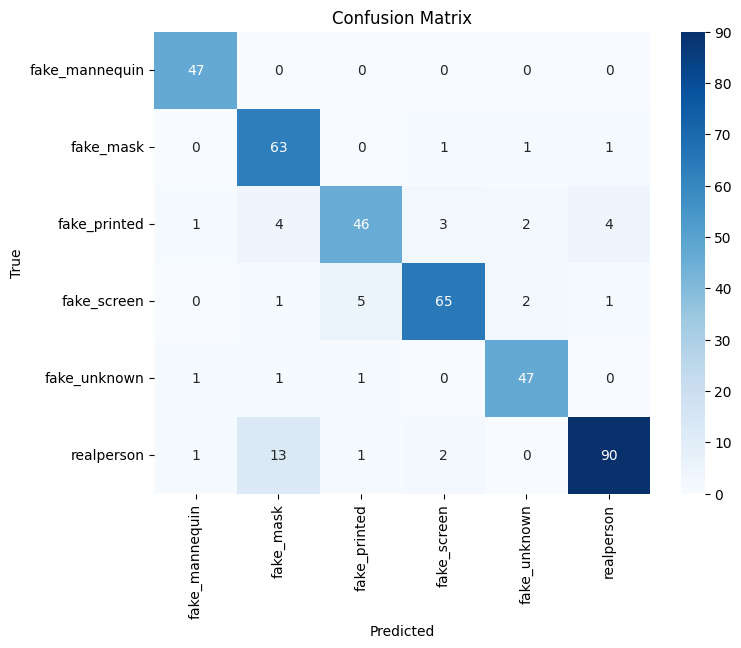

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    xticklabels=classes,
    yticklabels=classes,
    cmap="Blues",
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.show()

Total mistakes: 46


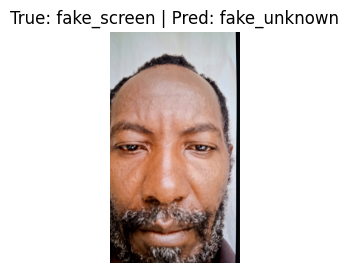

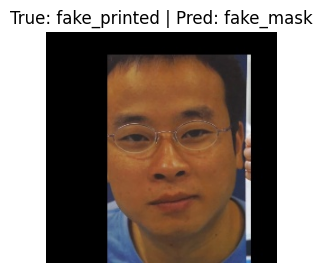

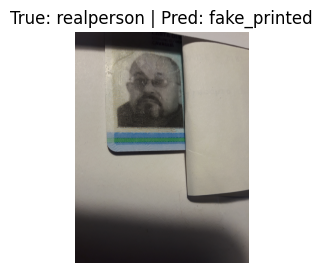

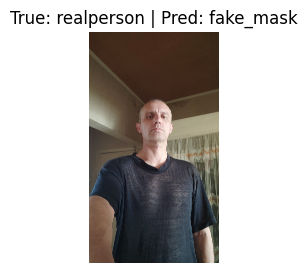

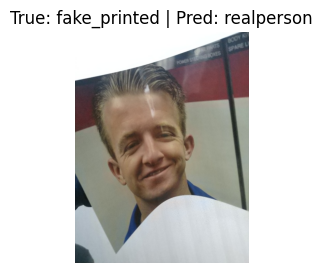

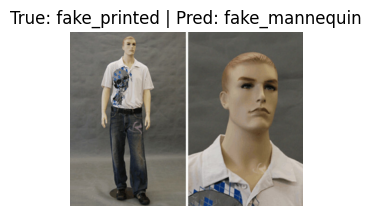

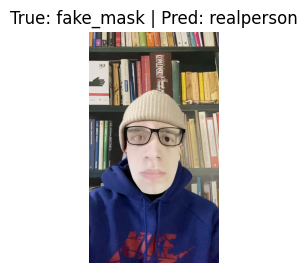

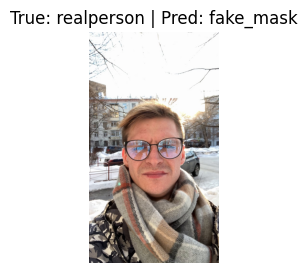

In [40]:
import random
import matplotlib.pyplot as plt

mistakes = df[df["label_true"] != df["label_pred"]]

print("Total mistakes:", len(mistakes))

sample = mistakes.sample(8)

for i,row in sample.iterrows():

    img_id = row["id"]
    path = os.path.join(TEST_PATH, img_id + ".jpg")

    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(3,3))
    plt.imshow(img)
    plt.title(f"True: {row['label_true']} | Pred: {row['label_pred']}")
    plt.axis("off")